<a href="https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/w06_validation_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

**Lane:** Refresh / Content Opportunity Scoring  
**Primary metric:** Precision@50  
**Unit of analysis:** One anonymised content page for one anonymised client  
**Feature window:** March 1–15, 2026  
**Outcome window:** March 16–31, 2026  
**Intended use:** Human decision-support for content-review prioritisation

This notebook audits the Week-5 Logistic Regression model using:

1. two constructive research-paper methodology questions;
2. a random-row versus grouped-client validation comparison;
3. a final feature leakage audit;
4. real false-positive and false-negative examples;
5. public-safe claim rewrites.

The notebook is self-contained and does not depend on running the Week-5 notebook.

## 1. Two paper findings + my methodology questions

### Finding 1 — Growing content was longer and younger than declining content

The FlyRank research paper reports that pages with rising impressions averaged approximately **3,180 words** and **184 days of age**, while pages with falling impressions averaged approximately **2,311 words** and **230 days of age**.

#### Where does the label come from?

The paper defines trend direction from the latest 30-day impression change compared with the previous 30-day period. I would ask whether pages with very low impression counts were filtered or stabilised before the growth or decline label was assigned, because small absolute changes can create large percentage movements.

#### Does the validation design carry the claim?

The comparison is observational rather than causal. The sample supports the measured difference inside the observed portfolio, but it does not prove that increasing word count or reducing content age causes growth. Client, topic, publication timing, search demand, and existing visibility may explain part of the measured difference.

**Public-safe interpretation:** Longer and younger pages were associated with stronger recent impression trends in the observed portfolio. The finding is directional and may support review prioritisation, but it is not a causal rule.

---

### Finding 2 — Recently refreshed mature content showed stronger measured performance

The paper reports that the **31–90 day freshness band** had the strongest stable growth-to-decline ratio. It also reports that mature pages refreshed within 30 days had higher measured health and impressions than older pages that had not been refreshed recently.

#### Where does the label come from?

Freshness is based on days since the last recorded content update. I would ask what type of change qualifies as an update. A full rewrite, a small metadata edit, and an automated timestamp change may create the same freshness value even though they represent different interventions.

#### Does the validation design carry the claim?

The comparison is observational. Refreshed pages may already have had stronger historical visibility, greater business value, better editorial quality, or higher search demand. A stronger design would compare refreshed and untouched pages with similar prior impressions, position, age, topic, and client context, or use a time-aware before-and-after design.

**Public-safe interpretation:** Recent refresh activity was associated with stronger measured performance among mature pages in the observed portfolio. This is a directional decision-support signal, not proof that refreshing any page will produce the same result.

In [1]:
import pandas as pd

paper_findings = pd.DataFrame(
    [
        {
            "finding": "Growing content was longer and younger",
            "reported_measure_1": "3,180 vs 2,311 average words",
            "reported_measure_2": "184 vs 230 average age in days",
            "label_source": (
                "Latest 30-day impression trend compared with "
                "the previous 30-day period"
            ),
            "evidence_type": "Observational cohort comparison",
            "methodology_question": (
                "Were low-impression pages filtered or stabilised before "
                "assigning the growth or decline label?"
            ),
            "safe_interpretation": (
                "Longer and younger pages were associated with stronger "
                "recent impression trends in the observed portfolio."
            ),
        },
        {
            "finding": (
                "Recently refreshed mature content showed "
                "stronger measured performance"
            ),
            "reported_measure_1": "3.2x health comparison",
            "reported_measure_2": "57x impression comparison",
            "label_source": "Days since the last recorded content update",
            "evidence_type": "Observational freshness comparison",
            "methodology_question": (
                "What type of edit qualified as an update, and were "
                "refreshed pages comparable with untouched pages?"
            ),
            "safe_interpretation": (
                "Recent refresh activity was associated with stronger "
                "measured performance among mature pages."
            ),
        },
    ]
)

display(paper_findings)

assert len(paper_findings) == 2

assert paper_findings[
    "safe_interpretation"
].str.contains(
    "associated",
    case=False,
).all()

assert paper_findings[
    "evidence_type"
].str.contains(
    "observational",
    case=False,
).all()

print(
    "Two paper findings and constructive "
    "methodology questions documented."
)

,finding,reported_measure_1,reported_measure_2,label_source,evidence_type,methodology_question,safe_interpretation
0,Growing content was longer and younger,"3,180 vs 2,311 average words",184 vs 230 average age in days,Latest 30-day impression trend compared with t...,Observational cohort comparison,Were low-impression pages filtered or stabilis...,Longer and younger pages were associated with ...
1,Recently refreshed mature content showed stron...,3.2x health comparison,57x impression comparison,Days since the last recorded content update,Observational freshness comparison,"What type of edit qualified as an update, and ...",Recent refresh activity was associated with st...


Two paper findings and constructive methodology questions documented.


## 2. My model under an honest split (before/after)

The Week-5 Logistic Regression model is re-run under two validation designs.

### Before — random row split

A random row split can place pages from the same client in both training and validation. Pages from the same client may share site structure, measurement patterns, and editorial practices. This may make the measured validation result optimistic.

### After — grouped client split

The grouped split places each anonymised client entirely in either training or validation. The same client cannot occur in both sets.

This better represents the deployment question:

> Can the model rank pages belonging to a client it did not observe during training?

Both experiments use the same operational population, feature set, target definition, Logistic Regression pipeline, test size, random seed, and Precision@50 calculation.

The grouped result is treated as the more honest result. The random result is retained only for the before-and-after validation audit.

### Environment and warehouse setup

The following cells install the required packages, open the internship repository, authenticate securely with Hugging Face, and connect DuckDB to the March 2026 warehouse partition.

In [2]:
%pip install -q     duckdb     huggingface_hub     scikit-learn     pandas     numpy     matplotlib     joblib

In [3]:
import os
import json
import subprocess
from pathlib import Path

import duckdb
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata
from huggingface_hub import whoami

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
TEST_SIZE = 0.20
TOP_K = 50
CLASSIFICATION_THRESHOLD = 0.50

np.random.seed(SEED)

REPO_URL = (
    "https://github.com/"
    "Zafar488/flyrank-ml-internship"
)

REPO_ROOT = Path(
    "/content/flyrank-ml-internship"
)

if Path.cwd().name == "flyrank-ml-internship":

    REPO_ROOT = Path.cwd()

elif not REPO_ROOT.exists():

    print(
        "Repository not found. "
        "Cloning repository..."
    )

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPO_URL,
            str(REPO_ROOT),
        ],
        check=True,
    )

os.chdir(REPO_ROOT)

OUTPUT_DIR = Path(
    "work/outputs/ml09"
)

MODEL_DIR = (
    OUTPUT_DIR
    / "models"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

HF_TOKEN = userdata.get(
    "HF_TOKEN"
)

if not HF_TOKEN:

    raise ValueError(
        "HF_TOKEN was not found. Add HF_TOKEN "
        "in Colab Secrets and enable notebook access."
    )

whoami(
    token=HF_TOKEN
)

print(
    "Hugging Face authentication successful."
)

con = duckdb.connect()

safe_token = HF_TOKEN.replace(
    "'",
    "''",
)

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

WAREHOUSE_ROOT = (
    "hf://datasets/"
    "FlyRank/internship-warehouse"
)

MARCH_FACT = (
    "read_parquet("
    f"'{WAREHOUSE_ROOT}/"
    "fact_content_daily_performance/"
    "month=2026-03/*.parquet'"
    ")"
)

print(
    "Repository root:",
    Path.cwd(),
)

print(
    "Output directory:",
    OUTPUT_DIR,
)

print(
    "Feature window: "
    "2026-03-01 to 2026-03-15"
)

print(
    "Outcome window: "
    "2026-03-16 to 2026-03-31"
)

Repository not found. Cloning repository...
Hugging Face authentication successful.
Repository root: /content/flyrank-ml-internship
Output directory: work/outputs/ml09
Feature window: 2026-03-01 to 2026-03-15
Outcome window: 2026-03-16 to 2026-03-31


### Source verification and modeling frame

The source is verified before modeling. One row is then created for each anonymised client-page pair.

Feature-window measurements use March 1–15. The target is constructed only from the later March 16–31 outcome window.

In [4]:
source_check = con.sql(
    f"""
    SELECT
        COUNT(*) AS total_rows,
        MIN(report_date) AS minimum_date,
        MAX(report_date) AS maximum_date,
        COUNT(
            DISTINCT client_hash_id
        ) AS unique_clients,
        COUNT(
            DISTINCT (
                client_hash_id,
                content_hash_id
            )
        ) AS unique_client_pages

    FROM {MARCH_FACT}
    """
).df()

display(
    source_check
)

minimum_date = pd.to_datetime(
    source_check.loc[
        0,
        "minimum_date",
    ]
).date()

maximum_date = pd.to_datetime(
    source_check.loc[
        0,
        "maximum_date",
    ]
).date()

assert str(minimum_date) == (
    "2026-03-01"
)

assert str(maximum_date) == (
    "2026-03-31"
)

print(
    "March 2026 source verification passed."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,minimum_date,maximum_date,unique_clients,unique_client_pages
0,9841378,2026-03-01,2026-03-31,55,331437


March 2026 source verification passed.


In [5]:
page_frame = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_impressions,
                    0
                )

                ELSE 0
            END
        ) AS feature_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_clicks,
                    0
                )

                ELSE 0
            END
        ) AS feature_clicks,

        AVG(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN gsc_avg_position
            END
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN gsc_avg_position
            END
        ) AS feature_position_volatility,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                 AND COALESCE(
                     gsc_impressions,
                     0
                 ) > 0

                THEN report_date
            END
        ) AS feature_active_days,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'

                 AND gsc_data_available IS TRUE

                THEN report_date
            END
        ) AS feature_available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'

                 AND gsc_data_available IS TRUE

                THEN COALESCE(
                    gsc_impressions,
                    0
                )

                ELSE 0
            END
        ) AS outcome_impressions,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'

                 AND gsc_data_available IS TRUE

                THEN report_date
            END
        ) AS outcome_available_days

    FROM {MARCH_FACT}

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

print(
    "Raw page rows:",
    f"{len(page_frame):,}",
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw page rows: 331,437


In [6]:
page_frame[
    "feature_ctr"
] = np.where(
    page_frame[
        "feature_impressions"
    ] > 0,

    page_frame[
        "feature_clicks"
    ]
    /
    page_frame[
        "feature_impressions"
    ],

    np.nan,
)

volatility_median = float(
    page_frame[
        "feature_position_volatility"
    ].median()
)

page_frame[
    "feature_position_volatility"
] = (
    page_frame[
        "feature_position_volatility"
    ]
    .fillna(
        volatility_median
    )
)

page_frame[
    "feature_daily_impressions"
] = np.where(
    page_frame[
        "feature_available_days"
    ] > 0,

    page_frame[
        "feature_impressions"
    ]
    /
    page_frame[
        "feature_available_days"
    ],

    np.nan,
)

page_frame[
    "outcome_daily_impressions"
] = np.where(
    page_frame[
        "outcome_available_days"
    ] > 0,

    page_frame[
        "outcome_impressions"
    ]
    /
    page_frame[
        "outcome_available_days"
    ],

    np.nan,
)

page_frame[
    "is_declining_proxy"
] = (
    page_frame[
        "outcome_daily_impressions"
    ]
    <
    0.80
    *
    page_frame[
        "feature_daily_impressions"
    ]
).astype(int)

page_frame[
    "log_feature_impressions"
] = np.log1p(
    page_frame[
        "feature_impressions"
    ]
)

page_frame[
    "position_band"
] = pd.cut(
    page_frame[
        "feature_avg_position"
    ],
    bins=[
        0,
        3,
        10,
        20,
    ],
    labels=[
        "Top 3",
        "Page 1",
        "Page 2",
    ],
    include_lowest=True,
)

model_frame = page_frame[
    (
        page_frame[
            "feature_impressions"
        ] >= 500
    )
    &
    (
        page_frame[
            "feature_available_days"
        ] >= 5
    )
    &
    (
        page_frame[
            "outcome_available_days"
        ] >= 5
    )
    &
    (
        page_frame[
            "feature_avg_position"
        ] > 0
    )
    &
    (
        page_frame[
            "feature_avg_position"
        ] <= 20
    )
    &
    (
        page_frame[
            "feature_ctr"
        ].notna()
    )
    &
    (
        page_frame[
            "position_band"
        ].notna()
    )
].copy()

model_frame = (
    model_frame
    .drop_duplicates(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Operational evaluation rows:",
    f"{len(model_frame):,}",
)

print(
    "Declining proxy rate:",
    round(
        model_frame[
            "is_declining_proxy"
        ].mean(),
        3,
    ),
)

print(
    "Number of clients:",
    model_frame[
        "client_hash_id"
    ].nunique(),
)

assert len(model_frame) > 0

assert model_frame[
    "feature_impressions"
].ge(500).all()

assert model_frame[
    "feature_available_days"
].ge(5).all()

assert model_frame[
    "outcome_available_days"
].ge(5).all()

assert model_frame[
    "feature_avg_position"
].gt(0).all()

assert model_frame[
    "feature_avg_position"
].le(20).all()

Operational evaluation rows: 34,038
Declining proxy rate: 0.309
Number of clients: 32


### Final feature set and model pipeline

The final features use only the historical feature window. Identifiers and outcome-window fields are not predictive inputs.

Median imputation, scaling, and one-hot encoding are fitted inside the model pipeline using training rows only.

In [7]:
numeric_features = [
    "log_feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
]

categorical_features = [
    "position_band",
]

feature_columns = (
    numeric_features
    +
    categorical_features
)

target_column = (
    "is_declining_proxy"
)

group_column = (
    "client_hash_id"
)

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)


def build_audit_model():

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            ),
        ]
    )


assert target_column not in feature_columns

assert group_column not in feature_columns

assert "content_hash_id" not in feature_columns

assert "outcome_impressions" not in feature_columns

assert (
    "outcome_daily_impressions"
    not in feature_columns
)

print(
    "Final feature set:",
    feature_columns,
)

print(
    "Model pipeline created."
)

Final feature set: ['log_feature_impressions', 'feature_clicks', 'feature_ctr', 'feature_avg_position', 'feature_active_days', 'feature_position_volatility', 'position_band']
Model pipeline created.


### Honest before/after validation comparison

The same Logistic Regression pipeline is evaluated under:

- a stratified random-row split;
- a grouped-client split.

Precision@50 is the primary operational metric. Average Precision and ROC-AUC are supporting ranking metrics. The positive base rate is shown so the model results can be compared with the prevalence of the target.

In [8]:
def prepare_evaluation_arrays(
    labels,
    scores,
):
    labels_array = np.asarray(
        labels,
        dtype=int,
    )

    scores_array = np.asarray(
        scores,
        dtype=float,
    )

    if labels_array.ndim != 1:

        raise ValueError(
            "Labels must be one-dimensional."
        )

    if scores_array.ndim != 1:

        raise ValueError(
            "Scores must be one-dimensional."
        )

    if len(labels_array) != len(scores_array):

        raise ValueError(
            "Labels and scores must have equal length."
        )

    if len(labels_array) == 0:

        raise ValueError(
            "Evaluation arrays cannot be empty."
        )

    if not np.isfinite(
        scores_array
    ).all():

        raise ValueError(
            "Scores contain NaN or infinite values."
        )

    return (
        labels_array,
        scores_array,
    )


def precision_at_k(
    labels,
    scores,
    k=50,
):
    labels_array, scores_array = (
        prepare_evaluation_arrays(
            labels,
            scores,
        )
    )

    effective_k = min(
        k,
        len(labels_array),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[
            ranked_indices
        ].mean()
    )


def recall_at_k(
    labels,
    scores,
    k=50,
):
    labels_array, scores_array = (
        prepare_evaluation_arrays(
            labels,
            scores,
        )
    )

    total_positives = int(
        labels_array.sum()
    )

    if total_positives == 0:

        return np.nan

    effective_k = min(
        k,
        len(labels_array),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[
            ranked_indices
        ].sum()
        /
        total_positives
    )


def evaluate_validation_design(
    validation_design,
    train_frame,
    validation_frame,
    scores,
    client_overlap,
):
    labels, score_array = (
        prepare_evaluation_arrays(
            validation_frame[
                target_column
            ],
            scores,
        )
    )

    if np.unique(labels).size != 2:

        raise ValueError(
            "Validation labels must contain both classes."
        )

    return {
        "validation_design": (
            validation_design
        ),
        "train_rows": int(
            len(train_frame)
        ),
        "validation_rows": int(
            len(validation_frame)
        ),
        "train_clients": int(
            train_frame[
                group_column
            ].nunique()
        ),
        "validation_clients": int(
            validation_frame[
                group_column
            ].nunique()
        ),
        "client_overlap": int(
            client_overlap
        ),
        "positive_base_rate": float(
            labels.mean()
        ),
        f"precision@{TOP_K}": (
            precision_at_k(
                labels,
                score_array,
                TOP_K,
            )
        ),
        f"recall@{TOP_K}": (
            recall_at_k(
                labels,
                score_array,
                TOP_K,
            )
        ),
        "average_precision": float(
            average_precision_score(
                labels,
                score_array,
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                labels,
                score_array,
            )
        ),
    }

In [9]:
# ============================================================
# BEFORE — RANDOM ROW SPLIT
# ============================================================

all_indices = np.arange(
    len(model_frame)
)

random_train_indices, random_validation_indices = (
    train_test_split(
        all_indices,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=model_frame[
            target_column
        ],
    )
)

random_train = (
    model_frame
    .iloc[
        random_train_indices
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

random_validation = (
    model_frame
    .iloc[
        random_validation_indices
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

random_train_clients = set(
    random_train[
        group_column
    ].unique()
)

random_validation_clients = set(
    random_validation[
        group_column
    ].unique()
)

random_client_overlap = len(
    random_train_clients.intersection(
        random_validation_clients
    )
)

random_model = build_audit_model()

random_model.fit(
    random_train[
        feature_columns
    ],
    random_train[
        target_column
    ],
)

random_scores = random_model.predict_proba(
    random_validation[
        feature_columns
    ]
)[:, 1]

random_result = evaluate_validation_design(
    validation_design=(
        "Before — random row split"
    ),
    train_frame=random_train,
    validation_frame=random_validation,
    scores=random_scores,
    client_overlap=random_client_overlap,
)

print(
    "Random-row split completed."
)

print(
    "Random split client overlap:",
    random_client_overlap,
)

Random-row split completed.
Random split client overlap: 25


In [10]:
# ============================================================
# AFTER — GROUPED CLIENT SPLIT
# ============================================================

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

group_train_indices, group_validation_indices = next(
    group_splitter.split(
        model_frame[
            feature_columns
        ],
        model_frame[
            target_column
        ],
        groups=model_frame[
            group_column
        ],
    )
)

group_train = (
    model_frame
    .iloc[
        group_train_indices
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

group_validation = (
    model_frame
    .iloc[
        group_validation_indices
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

group_train_clients = set(
    group_train[
        group_column
    ].unique()
)

group_validation_clients = set(
    group_validation[
        group_column
    ].unique()
)

group_client_overlap = len(
    group_train_clients.intersection(
        group_validation_clients
    )
)

assert group_client_overlap == 0

grouped_model = build_audit_model()

grouped_model.fit(
    group_train[
        feature_columns
    ],
    group_train[
        target_column
    ],
)

grouped_scores = grouped_model.predict_proba(
    group_validation[
        feature_columns
    ]
)[:, 1]

grouped_result = evaluate_validation_design(
    validation_design=(
        "After — grouped client split"
    ),
    train_frame=group_train,
    validation_frame=group_validation,
    scores=grouped_scores,
    client_overlap=group_client_overlap,
)

print(
    "Grouped-client split completed."
)

print(
    "Grouped split client overlap:",
    group_client_overlap,
)

Grouped-client split completed.
Grouped split client overlap: 0


In [11]:
split_comparison = pd.DataFrame(
    [
        random_result,
        grouped_result,
    ]
)

display(
    split_comparison.round(4)
)

random_precision_50 = float(
    random_result[
        f"precision@{TOP_K}"
    ]
)

grouped_precision_50 = float(
    grouped_result[
        f"precision@{TOP_K}"
    ]
)

precision_gap = (
    grouped_precision_50
    -
    random_precision_50
)

print(
    "Random split Precision@50:",
    round(
        random_precision_50,
        3,
    ),
)

print(
    "Grouped split Precision@50:",
    round(
        grouped_precision_50,
        3,
    ),
)

print(
    "Grouped minus random difference:",
    round(
        precision_gap,
        3,
    ),
)

print(
    "Random split client overlap:",
    random_client_overlap,
)

print(
    "Grouped split client overlap:",
    group_client_overlap,
)

if precision_gap < 0:

    split_interpretation = (
        "The grouped estimate was lower than the random-row estimate. "
        "This is directionally consistent with the random split being "
        "more optimistic, although one split does not prove the source."
    )

elif np.isclose(
    precision_gap,
    0,
):

    split_interpretation = (
        "The two estimates were similar on this run. The grouped "
        "design remains safer because it prevents client overlap."
    )

else:

    split_interpretation = (
        "The grouped estimate was higher on this holdout. The grouped "
        "design remains more honest because client overlap is zero."
    )

print(
    split_interpretation
)

assert random_client_overlap > 0

assert group_client_overlap == 0

assert len(
    split_comparison
) == 2

assert np.isfinite(
    random_scores
).all()

assert np.isfinite(
    grouped_scores
).all()

split_comparison.to_csv(
    OUTPUT_DIR
    / "before_after_split_comparison.csv",
    index=False,
)

print(
    "Honest before/after comparison completed."
)

,validation_design,train_rows,validation_rows,train_clients,validation_clients,client_overlap,positive_base_rate,precision@50,recall@50,average_precision,roc_auc
0,Before — random row split,27230,6808,29,28,25,0.3090,0.56,0.0133,0.4064,0.6323
1,After — grouped client split,18081,15957,25,7,0,0.3006,0.64,0.0067,0.3937,0.6175


Random split Precision@50: 0.56
Grouped split Precision@50: 0.64
Grouped minus random difference: 0.08
Random split client overlap: 25
Grouped split client overlap: 0
The grouped estimate was higher on this holdout. The grouped design remains more honest because client overlap is zero.
Honest before/after comparison completed.


The before/after table is a validation-design audit, not a competition between two favourable numbers.

The grouped split is preferred because it prevents pages from the same client appearing in both training and validation. Any measured gap is specific to this holdout and may vary under another seed or client group.

## 3. Leakage audit

The final feature set is audited against four questions:

1. Was the field available before the prediction moment?
2. Does it overlap the future outcome window?
3. Does it directly define or reproduce the target?
4. Is it an identifier or an existing decision rather than a predictive signal?

Only historical feature-window measurements are allowed into the model.

I also inspect real false-positive and false-negative examples from the grouped client holdout. A false positive may consume reviewer capacity, while a false negative may hide a page that later receives the declining proxy label.

All displayed examples remain anonymised and are interpreted as observed validation errors rather than proof of content quality or causal decline.

In [12]:
leakage_audit = pd.DataFrame(
    [
        {
            "field": "log_feature_impressions",
            "role": "model feature",
            "safe_for_model": True,
            "available_when": "March 1–15, 2026",
            "reason": (
                "Derived only from feature-window impressions."
            ),
        },
        {
            "field": "feature_clicks",
            "role": "model feature",
            "safe_for_model": True,
            "available_when": "March 1–15, 2026",
            "reason": (
                "Observed only in the historical feature window."
            ),
        },
        {
            "field": "feature_ctr",
            "role": "model feature",
            "safe_for_model": True,
            "available_when": "March 1–15, 2026",
            "reason": (
                "Calculated only from feature-window clicks "
                "and impressions."
            ),
        },
        {
            "field": "feature_avg_position",
            "role": "model feature",
            "safe_for_model": True,
            "available_when": "March 1–15, 2026",
            "reason": (
                "Observed before the outcome window."
            ),
        },
        {
            "field": "feature_active_days",
            "role": "model feature",
            "safe_for_model": True,
            "available_when": "March 1–15, 2026",
            "reason": (
                "Counts active days only in the feature window."
            ),
        },
        {
            "field": "feature_position_volatility",
            "role": "model feature",
            "safe_for_model": True,
            "available_when": "March 1–15, 2026",
            "reason": (
                "Calculated only from feature-window positions."
            ),
        },
        {
            "field": "position_band",
            "role": "model feature",
            "safe_for_model": True,
            "available_when": "March 1–15, 2026",
            "reason": (
                "Derived from feature-window average position."
            ),
        },
        {
            "field": "client_hash_id",
            "role": "grouping identifier",
            "safe_for_model": False,
            "available_when": "Available",
            "reason": (
                "Used for grouped validation, not prediction."
            ),
        },
        {
            "field": "content_hash_id",
            "role": "output identifier",
            "safe_for_model": False,
            "available_when": "Available",
            "reason": (
                "Used for deduplication and review output only."
            ),
        },
        {
            "field": "outcome_impressions",
            "role": "target construction",
            "safe_for_model": False,
            "available_when": "March 16–31, 2026",
            "reason": (
                "Measured after the prediction moment."
            ),
        },
        {
            "field": "outcome_daily_impressions",
            "role": "target construction",
            "safe_for_model": False,
            "available_when": "March 16–31, 2026",
            "reason": (
                "Contains future outcome information."
            ),
        },
        {
            "field": "is_declining_proxy",
            "role": "target",
            "safe_for_model": False,
            "available_when": "After the outcome window",
            "reason": (
                "This is the answer the model predicts."
            ),
        },
        {
            "field": "baseline_action_score",
            "role": "existing decision score",
            "safe_for_model": False,
            "available_when": "Existing system output",
            "reason": (
                "It may be used as a comparison baseline, "
                "but never as a learned-model input."
            ),
        },
    ]
)

display(
    leakage_audit
)

unsafe_fields = set(
    leakage_audit.loc[
        leakage_audit[
            "safe_for_model"
        ].eq(False),
        "field",
    ]
)

expected_feature_set = {
    "log_feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
    "position_band",
}

assert target_column not in feature_columns

assert group_column not in feature_columns

assert "client_hash_id" not in feature_columns

assert "content_hash_id" not in feature_columns

assert "outcome_impressions" not in feature_columns

assert (
    "outcome_daily_impressions"
    not in feature_columns
)

assert (
    "baseline_action_score"
    not in feature_columns
)

assert set(
    feature_columns
).isdisjoint(
    unsafe_fields
)

assert set(
    feature_columns
) == expected_feature_set

leakage_audit.to_csv(
    OUTPUT_DIR
    / "leakage_audit.csv",
    index=False,
)

print(
    "Leakage audit passed: no target, future field, "
    "identifier, or existing decision score enters the model."
)

,field,role,safe_for_model,available_when,reason
0,log_feature_impressions,model feature,True,"March 1–15, 2026",Derived only from feature-window impressions.
1,feature_clicks,model feature,True,"March 1–15, 2026",Observed only in the historical feature window.
2,feature_ctr,model feature,True,"March 1–15, 2026",Calculated only from feature-window clicks and...
3,feature_avg_position,model feature,True,"March 1–15, 2026",Observed before the outcome window.
4,feature_active_days,model feature,True,"March 1–15, 2026",Counts active days only in the feature window.
5,feature_position_volatility,model feature,True,"March 1–15, 2026",Calculated only from feature-window positions.
6,position_band,model feature,True,"March 1–15, 2026",Derived from feature-window average position.
7,client_hash_id,grouping identifier,False,Available,"Used for grouped validation, not prediction."
8,content_hash_id,output identifier,False,Available,Used for deduplication and review output only.
9,outcome_impressions,target construction,False,"March 16–31, 2026",Measured after the prediction moment.


Leakage audit passed: no target, future field, identifier, or existing decision score enters the model.


### Real grouped-holdout failure examples

The grouped holdout contains clients that were not observed during model training.

A probability threshold of 0.50 is used only for diagnostic classification.

- A **false positive** is predicted as declining although the future proxy is negative.
- A **false negative** receives the declining proxy but is predicted as non-declining.

The operational workflow remains ranking-based, so Precision@50 is still the primary metric.

In [13]:
grouped_predictions = (
    np.asarray(
        grouped_scores,
        dtype=float,
    )
    >=
    CLASSIFICATION_THRESHOLD
).astype(int)

error_frame = group_validation[
    [
        "client_hash_id",
        "content_hash_id",
        "feature_impressions",
        "feature_clicks",
        "feature_ctr",
        "feature_avg_position",
        "feature_active_days",
        "feature_position_volatility",
        "position_band",
        target_column,
    ]
].copy()

error_frame[
    "model_score"
] = np.asarray(
    grouped_scores,
    dtype=float,
)

error_frame[
    "prediction"
] = grouped_predictions

error_frame[
    "error_type"
] = np.select(
    [
        (
            error_frame[
                target_column
            ].eq(0)
            &
            error_frame[
                "prediction"
            ].eq(1)
        ),
        (
            error_frame[
                target_column
            ].eq(1)
            &
            error_frame[
                "prediction"
            ].eq(0)
        ),
    ],
    [
        "false_positive",
        "false_negative",
    ],
    default="correct",
)

error_counts = (
    error_frame[
        "error_type"
    ]
    .value_counts()
    .rename_axis(
        "error_type"
    )
    .reset_index(
        name="rows"
    )
)

display(
    error_counts
)

false_positives = (
    error_frame[
        error_frame[
            "error_type"
        ].eq(
            "false_positive"
        )
    ]
    .sort_values(
        "model_score",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

false_negatives = (
    error_frame[
        error_frame[
            "error_type"
        ].eq(
            "false_negative"
        )
    ]
    .assign(
        distance_from_threshold=lambda frame: (
            frame[
                "model_score"
            ]
            -
            CLASSIFICATION_THRESHOLD
        ).abs()
    )
    .sort_values(
        "distance_from_threshold"
    )
    .reset_index(
        drop=True
    )
)

public_error_columns = [
    "model_score",
    "feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
    "position_band",
]

print(
    "False positive rows:",
    f"{len(false_positives):,}",
)

print(
    "False negative rows:",
    f"{len(false_negatives):,}",
)

print(
    "Highest-scoring false positives:"
)

display(
    false_positives[
        public_error_columns
    ].head(10)
)

print(
    "False negatives closest to the threshold:"
)

display(
    false_negatives[
        public_error_columns
    ].head(10)
)

assert len(
    error_frame
) == len(
    group_validation
)

assert np.isfinite(
    error_frame[
        "model_score"
    ]
).all()

assert len(
    false_positives
) > 0

assert len(
    false_negatives
) > 0

false_positives.to_csv(
    OUTPUT_DIR
    / "false_positives_grouped.csv",
    index=False,
)

false_negatives.to_csv(
    OUTPUT_DIR
    / "false_negatives_grouped.csv",
    index=False,
)

,error_type,rows
0,correct,8982
1,false_positive,5269
2,false_negative,1706


False positive rows: 5,269
False negative rows: 1,706
Highest-scoring false positives:


,model_score,feature_impressions,feature_clicks,feature_ctr,feature_avg_position,feature_active_days,feature_position_volatility,position_band
0,0.743835,943.0,0.0,0.0,8.382560,15,11.921020,Page 1
1,0.738293,740.0,0.0,0.0,8.894893,15,10.648152,Page 1
2,0.733027,676.0,0.0,0.0,8.709308,15,10.075964,Page 1
3,0.726891,544.0,0.0,0.0,9.582610,15,8.533599,Page 1
4,0.726598,1008.0,0.0,0.0,9.547908,14,9.844973,Page 1
5,0.719700,529.0,0.0,0.0,8.150486,15,8.703132,Page 1
6,0.715838,532.0,0.0,0.0,7.846623,15,8.501523,Page 1
7,0.712702,512.0,0.0,0.0,9.983669,15,6.640078,Page 1
8,0.712116,672.0,0.0,0.0,9.787429,15,7.031592,Page 1
9,0.711447,574.0,0.0,0.0,9.454784,15,7.005537,Page 1


False negatives closest to the threshold:


,model_score,feature_impressions,feature_clicks,feature_ctr,feature_avg_position,feature_active_days,feature_position_volatility,position_band
0,0.499966,5011.0,12.0,0.002395,3.285120,15,0.537578,Page 1
1,0.499774,868.0,3.0,0.003456,1.741515,15,1.082347,Top 3
2,0.499647,534.0,2.0,0.003745,1.819752,15,1.214575,Top 3
3,0.499634,1128.0,0.0,0.000000,14.503023,15,5.762159,Page 2
4,0.499577,1012.0,3.0,0.002964,1.120658,15,0.354755,Top 3
5,0.499563,23705.0,46.0,0.001941,4.746578,15,0.411179,Page 1
6,0.499510,1523.0,5.0,0.003283,4.268746,15,0.738778,Page 1
7,0.499383,884.0,0.0,0.000000,12.707480,15,6.697304,Page 2
8,0.499355,1043.0,0.0,0.000000,15.131004,15,5.211151,Page 2
9,0.499322,6256.0,16.0,0.002558,4.528565,15,0.354816,Page 1


### Top-50 grouped review queue

The queue directly represents the primary operational metric.

Precision@50 is the observed positive rate among the 50 highest-scoring grouped-validation pages.

In [14]:
top_50_review = (
    error_frame
    .sort_values(
        "model_score",
        ascending=False,
        kind="mergesort",
    )
    .head(
        TOP_K
    )
    .copy()
    .reset_index(
        drop=True
    )
)

top_50_review.insert(
    0,
    "rank",
    np.arange(
        1,
        len(top_50_review) + 1,
    ),
)

top_50_true_positives = int(
    top_50_review[
        target_column
    ].sum()
)

top_50_false_positives = int(
    len(top_50_review)
    -
    top_50_true_positives
)

top_50_precision = float(
    top_50_review[
        target_column
    ].mean()
)

print(
    "Top-50 queue rows:",
    len(top_50_review),
)

print(
    "Observed positives:",
    top_50_true_positives,
)

print(
    "Observed negatives:",
    top_50_false_positives,
)

print(
    "Grouped Precision@50:",
    round(
        top_50_precision,
        3,
    ),
)

public_queue_columns = [
    "rank",
    "model_score",
    target_column,
    "feature_impressions",
    "feature_ctr",
    "feature_avg_position",
    "feature_position_volatility",
    "position_band",
]

display(
    top_50_review[
        public_queue_columns
    ].head(20)
)

assert len(
    top_50_review
) == TOP_K

assert np.isclose(
    top_50_precision,
    grouped_precision_50,
)

top_50_review.to_csv(
    OUTPUT_DIR
    / "top_50_grouped_review_queue.csv",
    index=False,
)

Top-50 queue rows: 50
Observed positives: 32
Observed negatives: 18
Grouped Precision@50: 0.64


,rank,model_score,is_declining_proxy,feature_impressions,feature_ctr,feature_avg_position,feature_position_volatility,position_band
0,1,0.805261,1,653.0,0.0,9.157493,21.105039,Page 1
1,2,0.751316,1,504.0,0.0,9.372902,11.372153,Page 1
2,3,0.743835,0,943.0,0.0,8.382560,11.921020,Page 1
3,4,0.738293,0,740.0,0.0,8.894893,10.648152,Page 1
4,5,0.733027,0,676.0,0.0,8.709308,10.075964,Page 1
5,6,0.729817,1,589.0,0.0,8.939220,9.396693,Page 1
6,7,0.728303,1,579.0,0.0,9.900844,8.542776,Page 1
7,8,0.726891,0,544.0,0.0,9.582610,8.533599,Page 1
8,9,0.726598,0,1008.0,0.0,9.547908,9.844973,Page 1
9,10,0.725637,1,530.0,0.0,9.708983,8.277110,Page 1


### Held-out permutation importance

Permutation importance is calculated only on grouped validation rows.

It measures how much validation Average Precision decreases when one feature is shuffled. A larger decrease means the fitted model relied more heavily on that feature for this validation result.

This describes model reliance, not causal importance.

,feature,importance_mean,importance_std,stable_positive
0,feature_ctr,0.06820,0.00196,True
1,position_band,0.03493,0.00229,True
2,feature_avg_position,0.01567,0.00304,True
3,feature_position_volatility,0.01234,0.00287,True
4,log_feature_impressions,0.00050,0.00109,False
5,feature_clicks,0.00023,0.00013,False
6,feature_active_days,-0.00189,0.00067,False


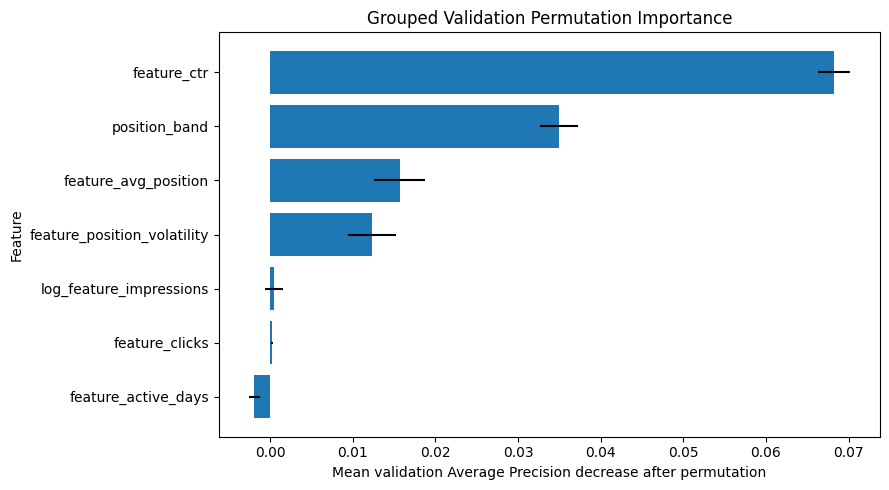

Saved importance figure: work/outputs/ml09/figures/grouped_permutation_importance.png


In [15]:
permutation_result = permutation_importance(
    grouped_model,
    group_validation[
        feature_columns
    ],
    group_validation[
        target_column
    ],
    scoring="average_precision",
    n_repeats=5,
    random_state=SEED,
    n_jobs=-1,
)

importance_table = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance_mean": (
            permutation_result
            .importances_mean
        ),
        "importance_std": (
            permutation_result
            .importances_std
        ),
    }
)

importance_table[
    "stable_positive"
] = (
    importance_table[
        "importance_mean"
    ]
    -
    2
    *
    importance_table[
        "importance_std"
    ]
    > 0
)

importance_table = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    importance_table.round(5)
)

importance_table.to_csv(
    OUTPUT_DIR
    / "grouped_permutation_importance.csv",
    index=False,
)

plot_importance = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

plt.figure(
    figsize=(
        9,
        5,
    )
)

plt.barh(
    plot_importance[
        "feature"
    ],
    plot_importance[
        "importance_mean"
    ],
    xerr=plot_importance[
        "importance_std"
    ],
)

plt.xlabel(
    "Mean validation Average Precision "
    "decrease after permutation"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Grouped Validation Permutation Importance"
)

plt.tight_layout()

importance_figure_path = (
    FIGURE_DIR
    / "grouped_permutation_importance.png"
)

plt.savefig(
    importance_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved importance figure:",
    importance_figure_path,
)

## 4. Claim rewrite

### Bold model claim

> Logistic Regression predicts which pages need a refresh.

### Public-safe rewrite

On the grouped client holdout used in this notebook, Logistic Regression measured a specific Precision@50 on client groups not observed during training.

The result is observed and directional and is intended for decision-support. It supports prioritising eligible pages for human review, but it does not prove that every selected page requires a refresh or that changing an individual feature will improve future search performance.

### Bold feature claim

> CTR causes page decline.

### Public-safe rewrite

Held-out permutation importance describes how much the fitted model relied on each feature for measured validation performance. A high importance value describes model behaviour on this grouped split and does not establish causation.

### Bold deployment claim

> The model should automatically decide which pages to refresh.

### Public-safe rewrite

The model is a decision-support ranking tool. It can help a human team decide which eligible pages to inspect first. Final refresh, expansion, CTR review, protection, monitoring, or no-action decisions still require human review.

In [16]:
grouped_average_precision = float(
    grouped_result[
        "average_precision"
    ]
)

grouped_roc_auc = float(
    grouped_result[
        "roc_auc"
    ]
)

top_features = (
    importance_table
    .head(3)[
        "feature"
    ]
    .tolist()
)

claim_audit = pd.DataFrame(
    [
        {
            "claim_type": "model performance",
            "unsafe_claim": (
                "The model predicts which pages "
                "need a refresh."
            ),
            "safe_claim": (
                f"On the grouped client holdout, "
                f"Logistic Regression measured "
                f"Precision@{TOP_K}="
                f"{grouped_precision_50:.3f}, "
                f"Average Precision="
                f"{grouped_average_precision:.3f}, "
                f"and ROC-AUC="
                f"{grouped_roc_auc:.3f}. "
                "The result is observed, measured, "
                "directional, and intended for "
                "decision-support."
            ),
        },
        {
            "claim_type": "feature interpretation",
            "unsafe_claim": (
                "The top feature causes page decline."
            ),
            "safe_claim": (
                f"The fitted model relied most on "
                f"{', '.join(top_features)} under "
                "held-out permutation importance. "
                "This describes measured model "
                "reliance and does not establish causation."
            ),
        },
        {
            "claim_type": "deployment",
            "unsafe_claim": (
                "The model should automate "
                "refresh decisions."
            ),
            "safe_claim": (
                "The model is a decision-support "
                "ranking tool. Human review remains "
                "required before any content action."
            ),
        },
    ]
)

display(
    claim_audit
)

safe_language = " ".join(
    claim_audit[
        "safe_claim"
    ].str.lower()
)

required_safe_words = [
    "observed",
    "measured",
    "directional",
    "decision-support",
    "human review",
]

for word in required_safe_words:

    assert word in safe_language, (
        f"Missing safe language: {word}"
    )

claim_audit.to_csv(
    OUTPUT_DIR
    / "claim_rewrite_audit.csv",
    index=False,
)

print(
    "Claim rewrite audit completed."
)

,claim_type,unsafe_claim,safe_claim
0,model performance,The model predicts which pages need a refresh.,"On the grouped client holdout, Logistic Regres..."
1,feature interpretation,The top feature causes page decline.,"The fitted model relied most on feature_ctr, p..."
2,deployment,The model should automate refresh decisions.,The model is a decision-support ranking tool. ...


Claim rewrite audit completed.


## Self-check

Before submission, this notebook confirms that:

- every required section contains markdown reasoning and supporting code;
- two paper findings are reviewed constructively;
- random-row and grouped-client validation are compared;
- the grouped split has zero client overlap;
- base rates are reported alongside ranking metrics;
- target-derived, future-window, identifier, and existing decision fields are excluded;
- real false-positive and false-negative examples are inspected;
- claims use observed, measured, directional, and decision-support language;
- the actual fitted grouped pipeline and audit outputs are saved;
- no placeholder values are used.

In [17]:
model_path = (
    MODEL_DIR
    / "ml09_grouped_logistic_regression.joblib"
)

joblib.dump(
    grouped_model,
    model_path,
)

assert hasattr(
    grouped_model,
    "predict_proba",
)

group_confusion = confusion_matrix(
    group_validation[
        target_column
    ],
    grouped_predictions,
    labels=[
        0,
        1,
    ],
)

tn, fp, fn, tp = (
    group_confusion.ravel()
)

group_confusion_table = pd.DataFrame(
    group_confusion,
    index=[
        "Actual not declining",
        "Actual declining",
    ],
    columns=[
        "Predicted not declining",
        "Predicted declining",
    ],
)

display(
    group_confusion_table
)

group_confusion_table.to_csv(
    OUTPUT_DIR
    / "grouped_confusion_matrix.csv"
)

classification_report_df = pd.DataFrame(
    classification_report(
        group_validation[
            target_column
        ],
        grouped_predictions,
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(
    classification_report_df.round(4)
)

classification_report_df.to_csv(
    OUTPUT_DIR
    / "grouped_classification_report.csv"
)

positive_precision = float(
    classification_report_df.loc[
        "1",
        "precision",
    ]
)

positive_recall = float(
    classification_report_df.loc[
        "1",
        "recall",
    ]
)

print(
    "Threshold diagnostic only:"
)

print(
    "Positive-class precision:",
    round(
        positive_precision,
        4,
    ),
)

print(
    "Positive-class recall:",
    round(
        positive_recall,
        4,
    ),
)

print(
    "Primary operational metric remains "
    "Precision@50, not threshold accuracy."
)

audit_receipt = {
    "assignment": "ML-09",
    "lane": (
        "Refresh / Content Opportunity Scoring"
    ),
    "feature_window": (
        "2026-03-01 to 2026-03-15"
    ),
    "outcome_window": (
        "2026-03-16 to 2026-03-31"
    ),
    "model": (
        "Logistic Regression"
    ),
    "before_split": (
        "Random row split"
    ),
    "after_split": (
        "GroupShuffleSplit by client_hash_id"
    ),
    "random_client_overlap": int(
        random_client_overlap
    ),
    "grouped_client_overlap": int(
        group_client_overlap
    ),
    "random_positive_base_rate": float(
        random_result[
            "positive_base_rate"
        ]
    ),
    "grouped_positive_base_rate": float(
        grouped_result[
            "positive_base_rate"
        ]
    ),
    "random_precision_at_50": float(
        random_precision_50
    ),
    "grouped_precision_at_50": float(
        grouped_precision_50
    ),
    "grouped_average_precision": float(
        grouped_average_precision
    ),
    "grouped_roc_auc": float(
        grouped_roc_auc
    ),
    "threshold": float(
        CLASSIFICATION_THRESHOLD
    ),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
    "positive_class_precision": float(
        positive_precision
    ),
    "positive_class_recall": float(
        positive_recall
    ),
    "top_50_true_positives": int(
        top_50_true_positives
    ),
    "top_50_false_positives": int(
        top_50_false_positives
    ),
    "top_permutation_features": (
        top_features
    ),
    "primary_metric": (
        "Precision@50"
    ),
    "usage": (
        "Human decision-support review queue"
    ),
    "causal_claim": False,
    "placeholder_values_used": False,
}

audit_receipt_path = (
    OUTPUT_DIR
    / "ml09_audit_receipt.json"
)

with open(
    audit_receipt_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        audit_receipt,
        file,
        indent=2,
    )

required_files = [
    OUTPUT_DIR
    / "before_after_split_comparison.csv",

    OUTPUT_DIR
    / "leakage_audit.csv",

    OUTPUT_DIR
    / "false_positives_grouped.csv",

    OUTPUT_DIR
    / "false_negatives_grouped.csv",

    OUTPUT_DIR
    / "top_50_grouped_review_queue.csv",

    OUTPUT_DIR
    / "grouped_permutation_importance.csv",

    OUTPUT_DIR
    / "claim_rewrite_audit.csv",

    OUTPUT_DIR
    / "grouped_classification_report.csv",

    OUTPUT_DIR
    / "grouped_confusion_matrix.csv",

    audit_receipt_path,

    importance_figure_path,

    model_path,
]

self_checks = {
    "Two paper findings documented": (
        len(paper_findings) == 2
    ),

    "Paper findings are observational": (
        paper_findings[
            "evidence_type"
        ]
        .str.contains(
            "observational",
            case=False,
        )
        .all()
    ),

    "Before and after validation completed": (
        len(split_comparison) == 2
    ),

    "Random split has client overlap": (
        random_client_overlap > 0
    ),

    "Grouped client overlap equals zero": (
        group_client_overlap == 0
    ),

    "Random base rate is valid": (
        0
        <= random_result[
            "positive_base_rate"
        ]
        <= 1
    ),

    "Grouped base rate is valid": (
        0
        <= grouped_result[
            "positive_base_rate"
        ]
        <= 1
    ),

    "Leakage audit completed": (
        len(leakage_audit) >= 10
    ),

    "Target excluded from features": (
        target_column
        not in feature_columns
    ),

    "Identifiers excluded from features": (
        group_column
        not in feature_columns

        and

        "content_hash_id"
        not in feature_columns
    ),

    "Outcome fields excluded": (
        "outcome_impressions"
        not in feature_columns

        and

        "outcome_daily_impressions"
        not in feature_columns
    ),

    "Existing decision score excluded": (
        "baseline_action_score"
        not in feature_columns
    ),

    "False positives inspected": (
        len(false_positives) > 0
    ),

    "False negatives inspected": (
        len(false_negatives) > 0
    ),

    "Top-50 queue contains 50 rows": (
        len(top_50_review) == TOP_K
    ),

    "Grouped Precision@50 is valid": (
        0
        <= grouped_precision_50
        <= 1
    ),

    "Safe claim language checked": all(
        word in safe_language
        for word in required_safe_words
    ),

    "Actual fitted pipeline saved": (
        hasattr(
            grouped_model,
            "predict_proba",
        )

        and

        model_path.exists()
    ),

    "No placeholder values used": (
        audit_receipt[
            "placeholder_values_used"
        ]
        is False
    ),

    "Required outputs exist": all(
        path.exists()
        for path in required_files
    ),
}

self_check_df = pd.DataFrame(
    {
        "check": list(
            self_checks.keys()
        ),
        "passed": list(
            self_checks.values()
        ),
    }
)

display(
    self_check_df
)

failed_checks = [
    check_name
    for check_name, passed
    in self_checks.items()
    if not passed
]

if failed_checks:

    raise AssertionError(
        "Self-check failed: "
        +
        ", ".join(
            failed_checks
        )
    )

print(
    "Saved grouped model:",
    model_path,
)

print(
    "Saved ML-09 outputs:",
    OUTPUT_DIR,
)

print(
    "All ML-09 self-checks passed."
)

,Predicted not declining,Predicted declining
Actual not declining,5891,5269
Actual declining,1706,3091


,precision,recall,f1-score,support
0,0.7754,0.5279,0.6281,11160.0000
1,0.3697,0.6444,0.4699,4797.0000
accuracy,0.5629,0.5629,0.5629,0.5629
macro avg,0.5726,0.5861,0.5490,15957.0000
weighted avg,0.6535,0.5629,0.5806,15957.0000


Threshold diagnostic only:
Positive-class precision: 0.3697
Positive-class recall: 0.6444
Primary operational metric remains Precision@50, not threshold accuracy.


,check,passed
0,Two paper findings documented,True
1,Paper findings are observational,True
2,Before and after validation completed,True
3,Random split has client overlap,True
4,Grouped client overlap equals zero,True
5,Random base rate is valid,True
6,Grouped base rate is valid,True
7,Leakage audit completed,True
8,Target excluded from features,True
9,Identifiers excluded from features,True


Saved grouped model: work/outputs/ml09/models/ml09_grouped_logistic_regression.joblib
Saved ML-09 outputs: work/outputs/ml09
All ML-09 self-checks passed.
